# LOGISTIC REGRESSION:  
## 1. Data Exploration:  
a. Load the dataset and perform exploratory data analysis (EDA).    
b. Examine the features, their types, and summary statistics.    
c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

**a. Load the dataset and perform exploratory data analysis (EDA).**

In [1]:
# Load the Dataset 
import pandas as pd 
df = pd.read_csv("diabetes.csv")

In [2]:
# Head of Dataset 
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Tail of Dataset 
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


**b. Examine the features, their types, and summary statistics.**

In [4]:
# Shape of Dataset 
df.shape

(768, 9)

In [5]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Statistical Summary 
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features. Analyze any patterns or correlations observed in the data.**

In [7]:
# Extract the Numrical columns and categorical columns 
num_cols = df.select_dtypes(include = ['int','float']).columns
cat_cols = df.select_dtypes(include = 'object').columns

print("Numerical Columns\n", num_cols)
print("Categorical Columns \n",cat_cols)

Numerical Columns
 Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')
Categorical Columns 
 Index([], dtype='object')


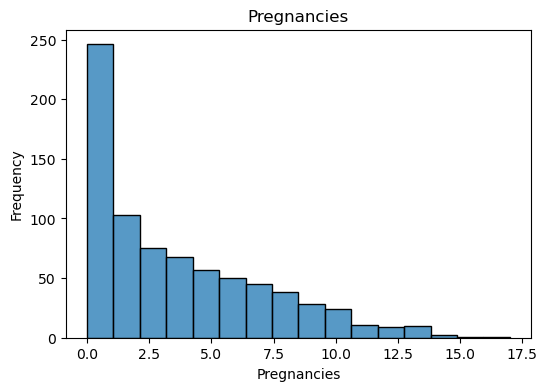

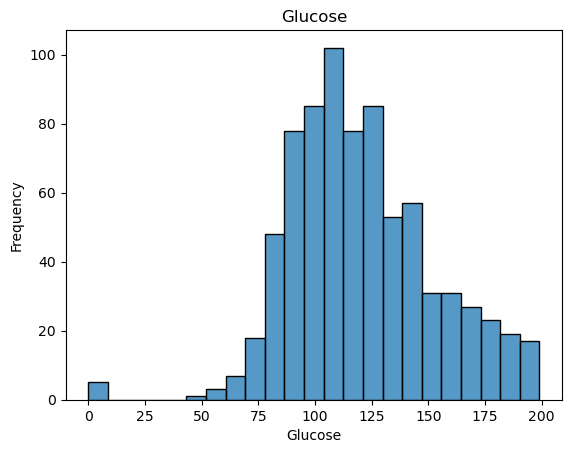

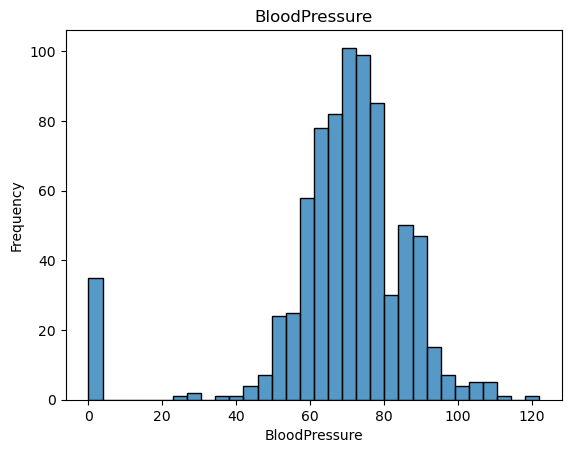

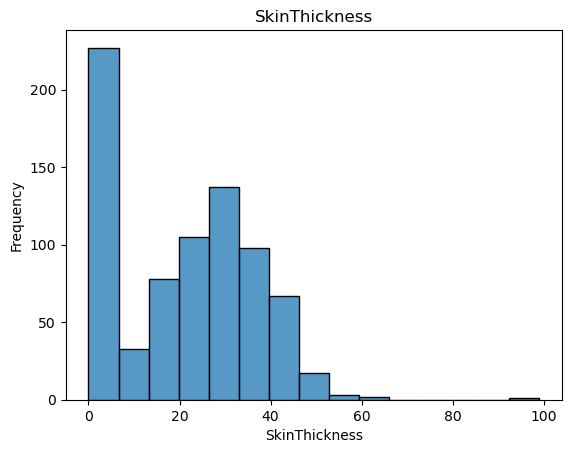

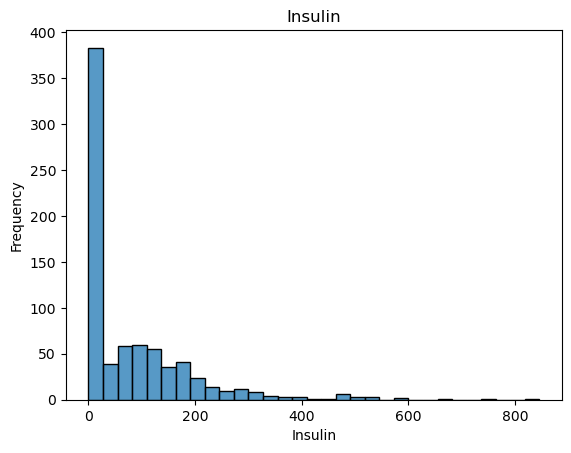

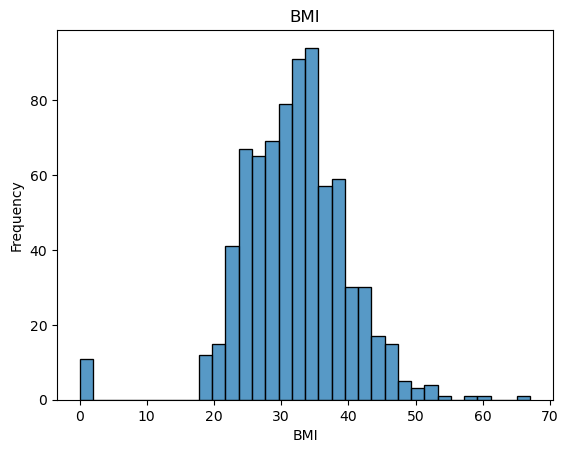

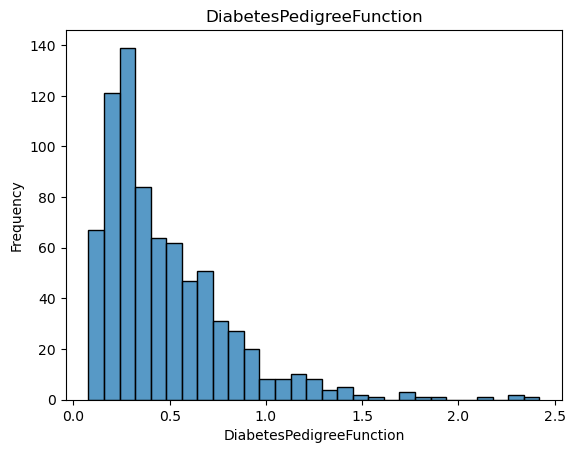

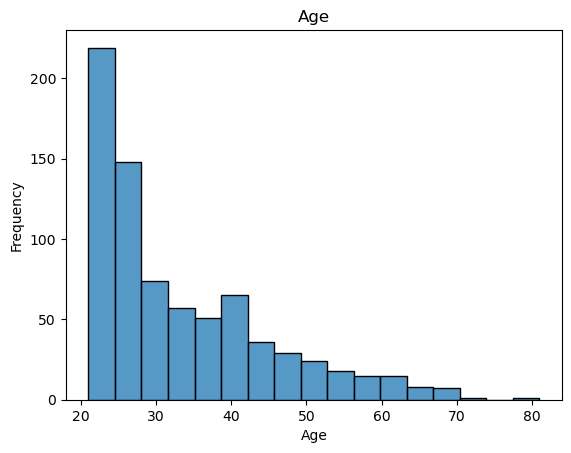

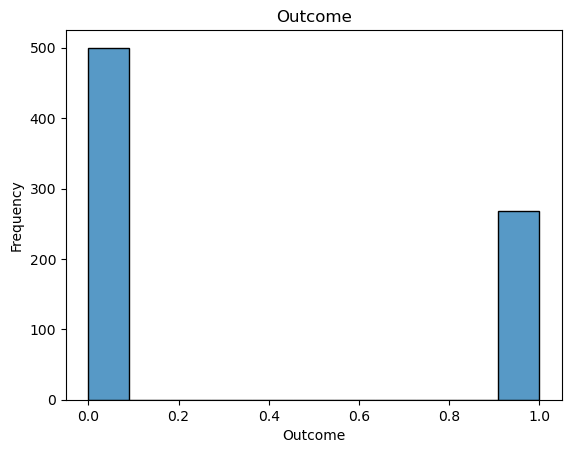

In [8]:
# Hist Plot for Numerical columns
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.figure(figsize = (6,4))
for col in num_cols :
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

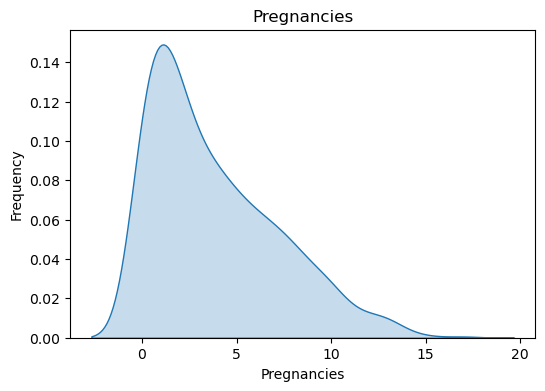

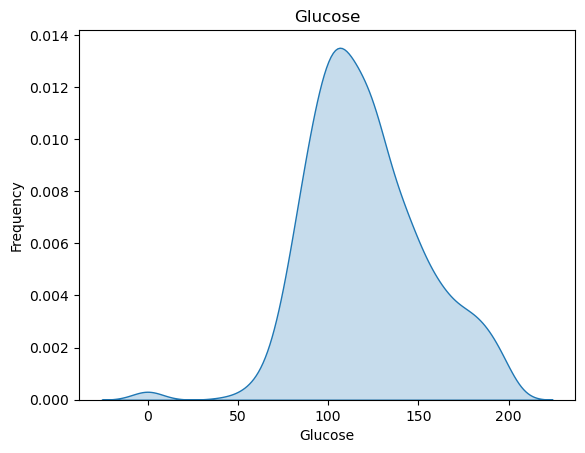

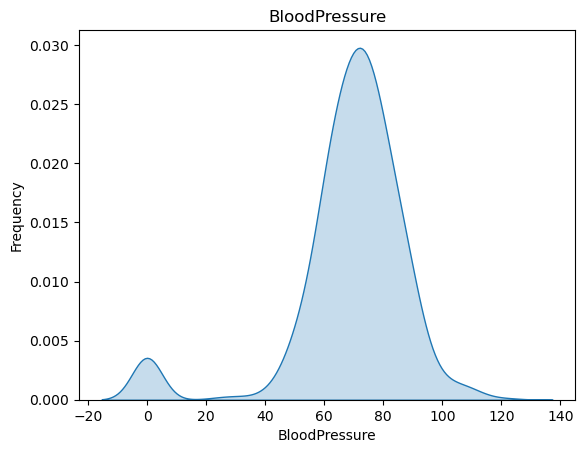

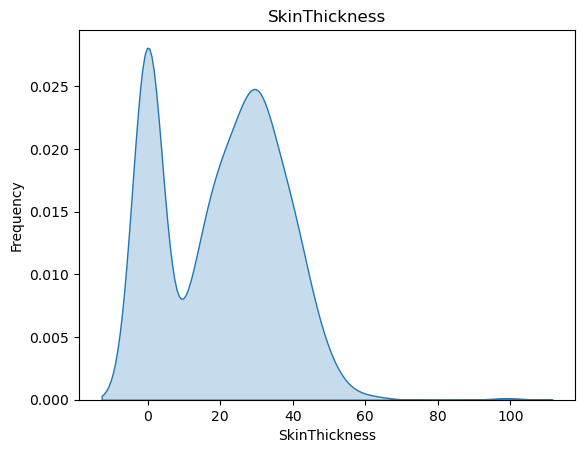

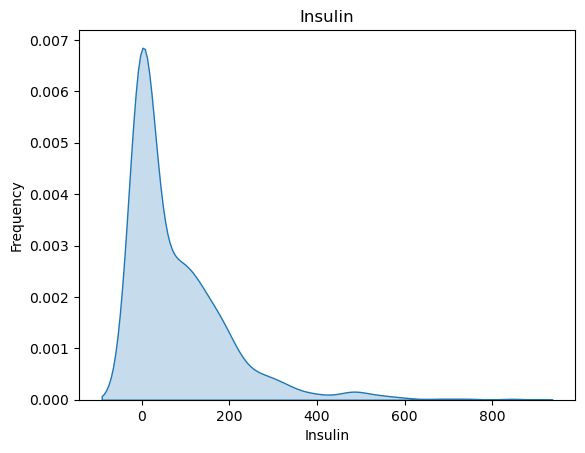

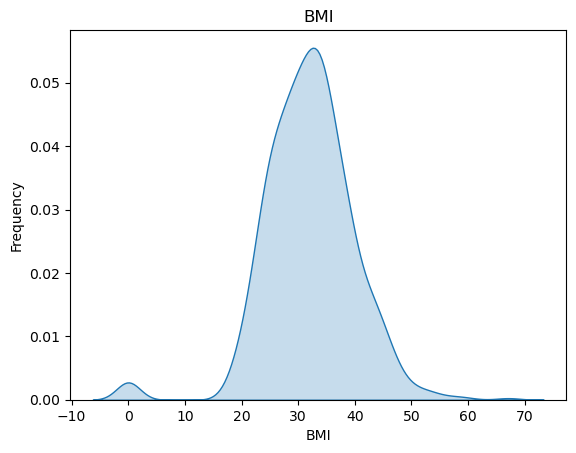

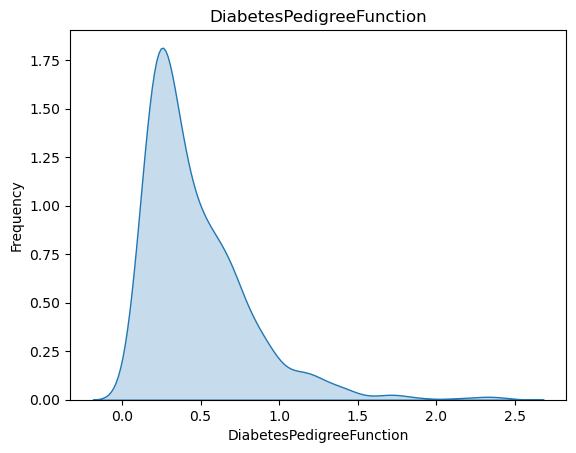

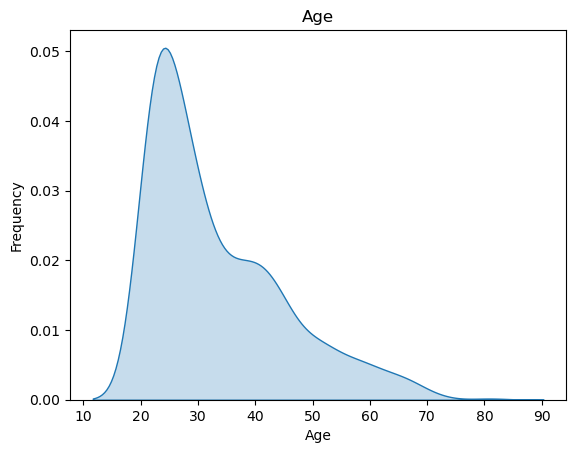

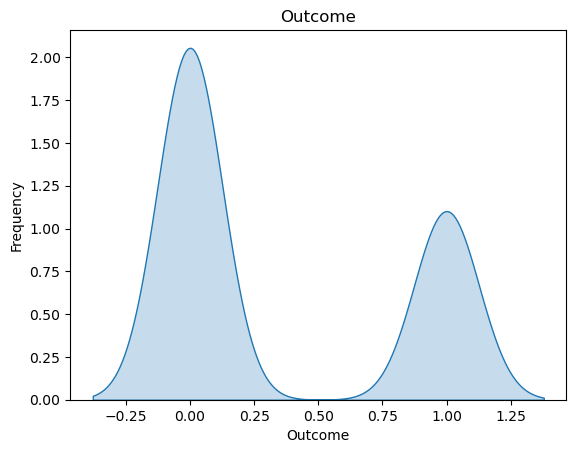

In [9]:
# KDE Plot for Numerical Columns 
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize = (6,4))
for col in num_cols: 
    sns.kdeplot(df[col], fill = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

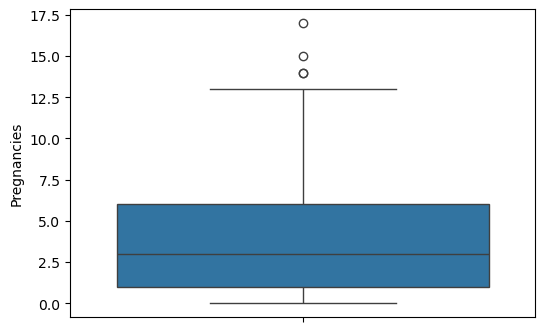

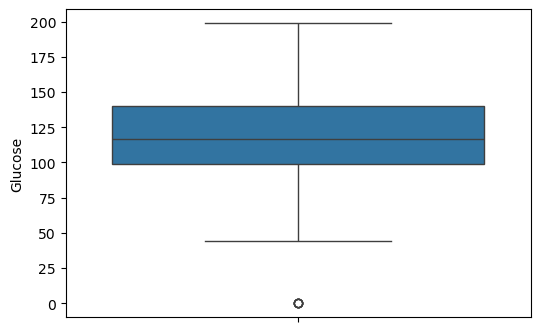

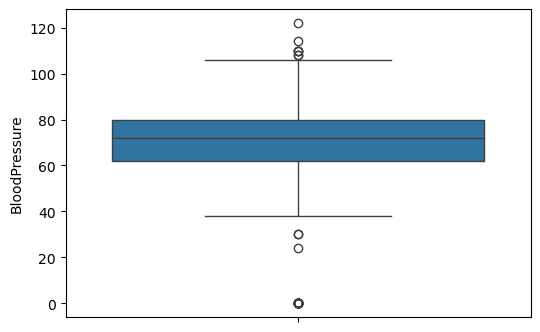

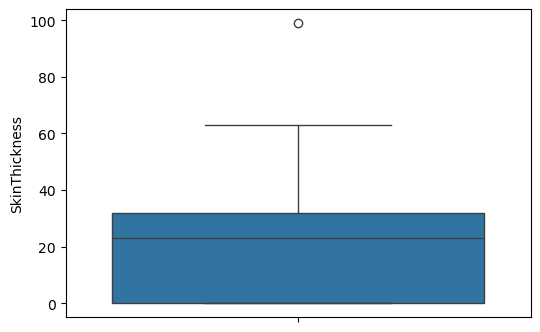

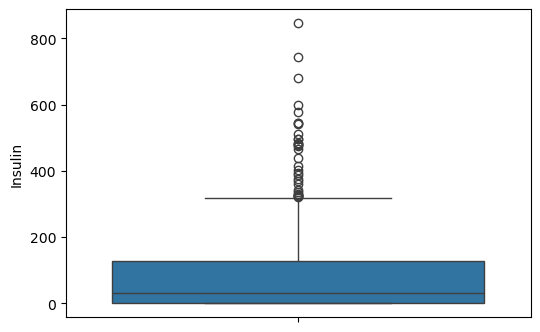

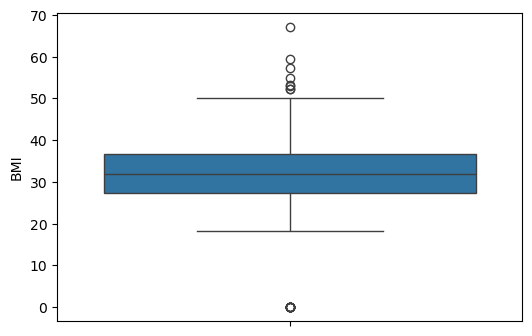

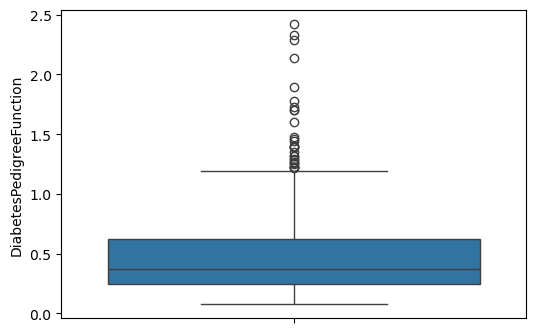

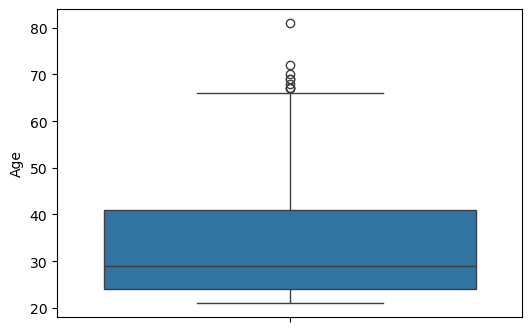

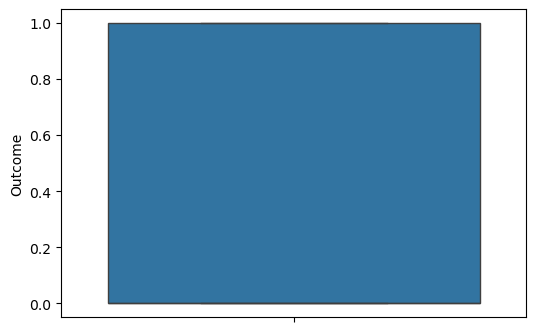

In [10]:
# Box Plot for Numerical columns 
import matplotlib.pyplot as plt 
import seaborn as sns 

for col in num_cols :
    plt.figure(figsize = (6,4))
    sns.boxplot(df[col])
    plt.show()

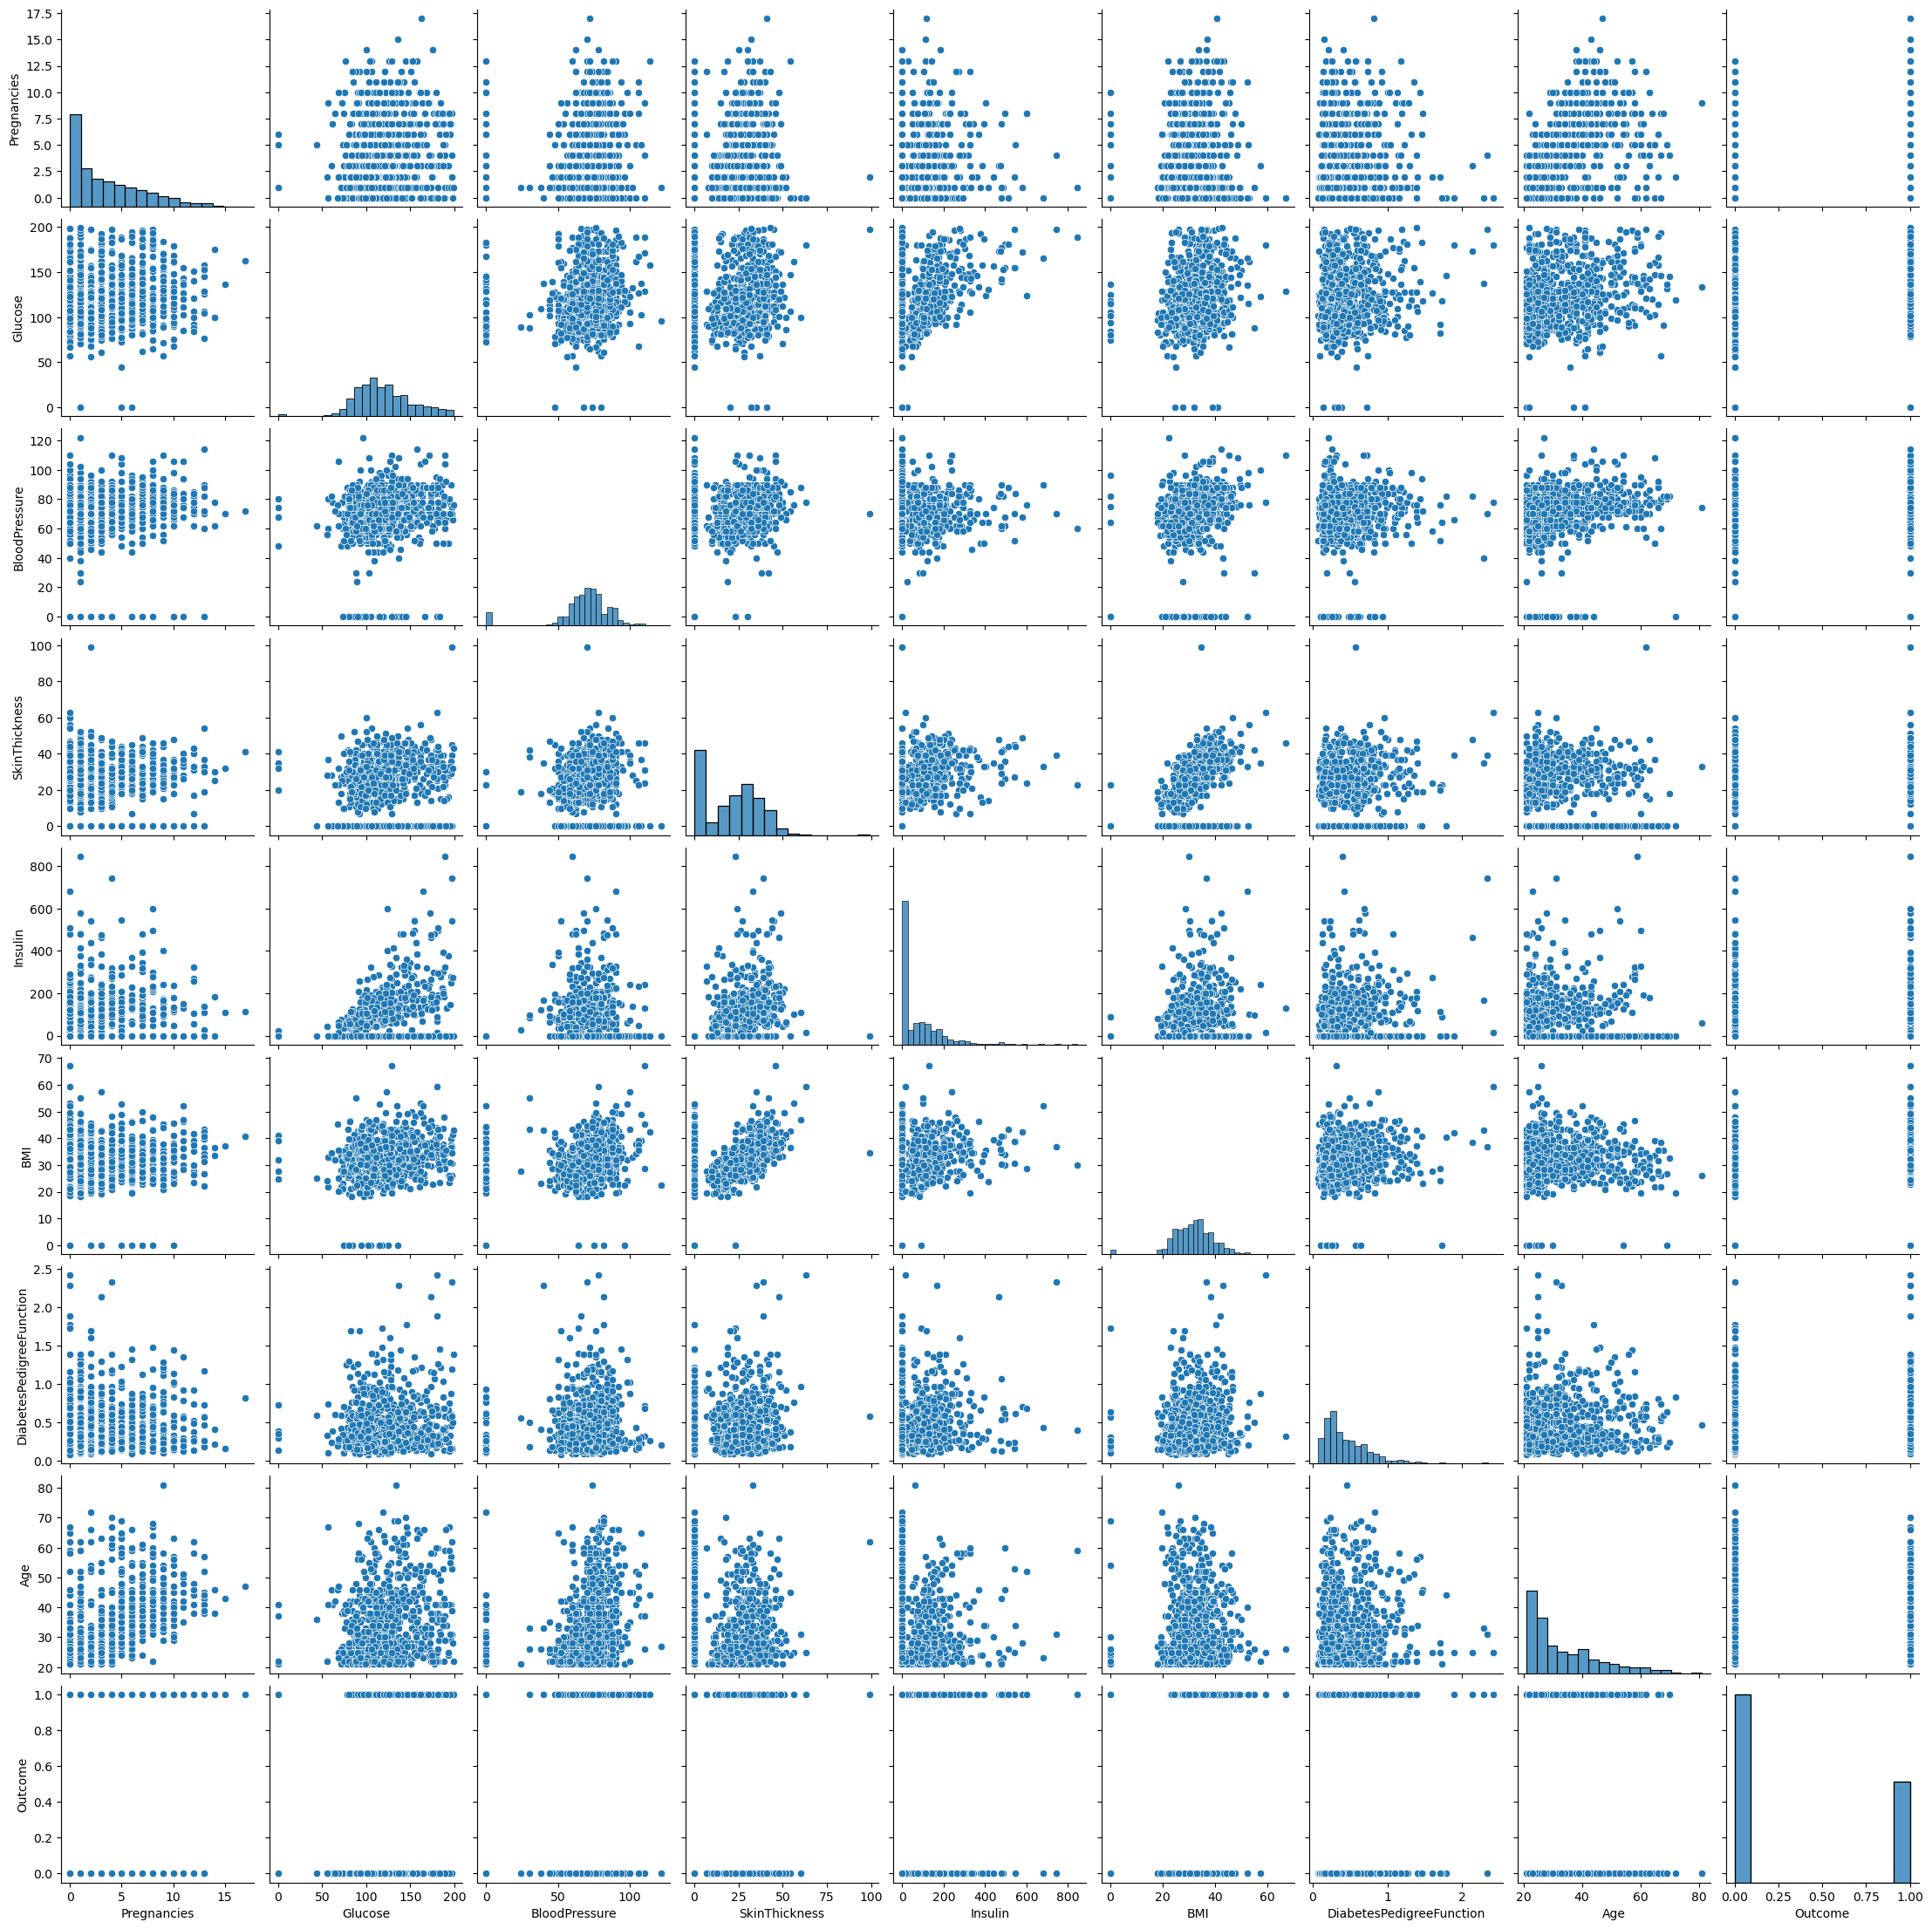

In [11]:
# Pair Plot 
import matplotlib.pyplot as plt 
import seaborn as sns

sns.pairplot(df)
plt.show()

## 2. Data Preprocessing:   
**a. Handle missing values (e.g., imputation).**  

In [12]:
# Check Missing Values 
missing = pd.DataFrame({
    "Missing"  : df.isnull().sum(),
    "Percentage" : (df.isnull().sum() / len(df) )  *100
})
missing.sort_values('Percentage',ascending = False)

,Missing,Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


In [13]:
# Check Duplicate Values 
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check Ouitliers 
for col in num_cols :
    sns.boxplot(df[col])
    plt.show()

**b. Encode categorical variables.   
There is no any categorical variables in this dataset. Therefore no need to Encoding**

In [15]:
# Ouitlier Capping 
for i in df.select_dtypes(include = ['int','float']).columns:
    q1 = df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    IQR = q1 - q3

    lower_bound = q1 - 1.5* IQR
    upper_bound = q3 + 1.5* IQR

    df[i] = df[i].clip(lower_bound, upper_bound)

In [ ]:
# Verify 
for col in num_cols:
    sns.boxplot(df[col])
    plt.show()

## 3. Model Building:  
**a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).**   

In [17]:
# Extract Features and Target 
x = df.drop(columns = 'Outcome') #(Features)
y = df['Outcome'] #(Target)

In [18]:
# Train_Test_Split 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [19]:
# Final Train_test_split shape : 
print("x_tarin:", x_train.shape)
print("x_test:", x_test.shape )
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_tarin: (614, 8)
x_test: (154, 8)
y_train: (614,)
y_test: (154,)


In [20]:
# Scaling 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

**b. Train the model using the training data.**

In [21]:
# Model Building : (Logistic Regression )
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

# Train the model 
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## 4. Model Evaluation:  
**a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.**

Accuracy Score : 0.7402597402597403
Precision Score : 0.6271186440677966
Recall Score: 0.6727272727272727
ROC_AUC: 0.7252525252525254


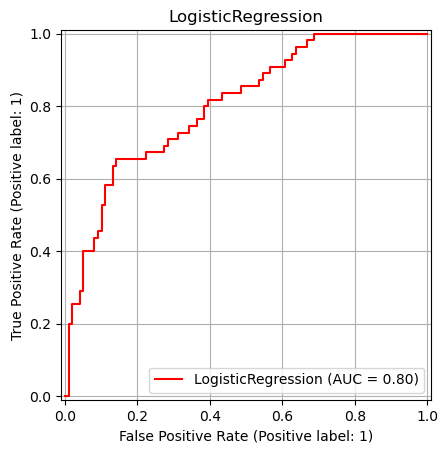

In [22]:
# Model Evaluation 
# Import Libraries
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

# Prediction 
lr_pred = lr.predict(x_test)

# Metrics 
print("Accuracy Score :", accuracy_score(y_test, lr_pred))
print("Precision Score :", precision_score(y_test, lr_pred))
print("Recall Score:", recall_score (y_test, lr_pred))
print("ROC_AUC:", roc_auc_score(y_test, lr_pred))

# Display ROC Curve 
RocCurveDisplay.from_estimator(
    lr,
    x_test, 
    y_test,
    color = 'red',
   )
plt.title(lr.__class__.__name__)
plt.grid(True)
plt.show()

## 5. Interpretation:  
**a. Interpret the coefficients of the logistic regression model.**  

In [23]:
# Restore the columns into DataFrame (Because of at the time of scaling the columns was converted into array)
x_train = pd.DataFrame(
    x_train,
    columns=x.columns
)

x_test = pd.DataFrame(
    x_test,
    columns=x.columns
)

In [24]:
# Interpret the cofficients of the logistic regression model
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lr.coef_[0]
})

coef_df

,Feature,Coefficient
0,Pregnancies,0.090253
1,Glucose,1.051133
2,BloodPressure,-0.296741
3,SkinThickness,0.036350
4,Insulin,-0.185727
5,BMI,0.779515
6,DiabetesPedigreeFunction,0.339006
7,Age,0.615126


**b. Discuss the significance of features in predicting the target variable (survival probability in this case).**  
| Feature                      | Coefficient | Interpretation                                                                                                                                                                                                   |
| ---------------------------- | ----------: | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Pregnancies**              |      0.0903 | A higher number of pregnancies slightly increases the likelihood of diabetes.                                                                                                                                    |
| **Glucose**                  |      1.0511 | Glucose has the strongest positive effect. Higher glucose levels significantly increase the probability of diabetes.                                                                                             |
| **BloodPressure**            |     -0.2967 | Higher blood pressure is associated with a lower predicted probability of diabetes in this model. This result should be interpreted cautiously because it may be influenced by correlations with other features. |
| **SkinThickness**            |      0.0364 | Skin thickness has a very small positive effect on the probability of diabetes.                                                                                                                                  |
| **Insulin**                  |     -0.1857 | Higher insulin values slightly decrease the predicted probability of diabetes in this model, though this may be due to interactions with other variables.                                                        |
| **BMI**                      |      0.7795 | A higher BMI substantially increases the likelihood of diabetes, making it one of the most important predictors.                                                                                                 |
| **DiabetesPedigreeFunction** |      0.3390 | A stronger family history of diabetes increases the probability of developing diabetes.                                                                                                                          |
| **Age**                      |      0.6151 | Older individuals have a higher probability of diabetes compared to younger individuals.                                                                                                                         |


## 6. Deployment with Streamlit:   
In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions.

(optional)For online deployment, use Streamlit Community Cloud, which supports deployment from GitHub repositories. Detailed deployment instructions are available in the Streamlit Documentation. https://docs.streamlit.io/streamlit-community-cloud/deploy-your-app 

In [25]:
# Save the Model 
import joblib
joblib.dump(lr, "diabetes_prediction.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

## 7. Interview Questions:  
What is the difference between precision and recall?  
What is cross-validation, and why is it important in binary classification?  

In [33]:
#Pregnancies	Glucose	BloodPressure	SkinThickness	Insulin	BMI	DiabetesPedigreeFunction	Age	Outcome
df['Glucose'].unique().min()

np.float64(78.375)

In [ ]:
df['']